
# Esercizio da esame — Stabilità nel calcolo di $$1-\cos(x)$$


Per ogni $$k \in \mathbb{N},$$ si consideri

$$
x_k = 10^{-k}
$$

e la quantità

$$
y_k = 1-\cos(x_k).
$$

Si considerino i valori

$$
k = 1,2,\dots,16.
$$

Per valori piccoli di $$x_k,$$ il calcolo diretto può essere affetto da instabilità numerica.

### Richieste

1. Implementare in Python il calcolo diretto di $y_k$.  
**[0.5 punti]**

2. Calcolare un valore di riferimento accurato usando aritmetica in precisione elevata e calcolare l'errore relativo della formula diretta.  
**[1.0 punti]**

3. Rappresentare in scala logaritmica l'errore relativo della formula diretta al variare di $x_k$.  
**[0.5 punti]**

4. Osservando i risultati numerici, spiegare dove avviene la cancellazione di cifre significative e ricavare teoricamente per quali valori di $x_k$ si verifica, usando anche il concetto di spacing.  
**[4 punti]**

5. Ricavare una formula matematicamente equivalente ma numericamente più stabile per il calcolo di $y_k$.  
**[2 punti]**

6. Implementare la formula stabile proposta, confrontarne l'errore relativo con quello della formula diretta e giustificare i risultati ottenuti.  
**[3.0 punti]**

Totale: **11 punti**.


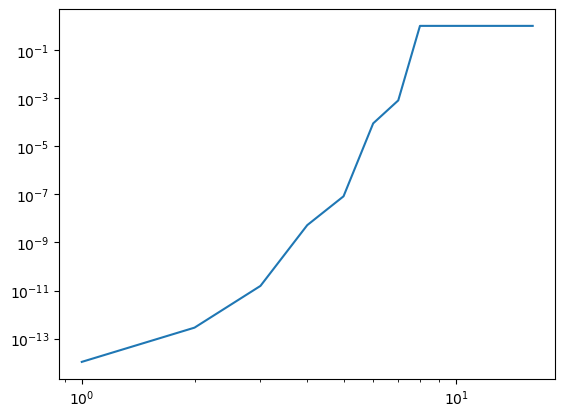

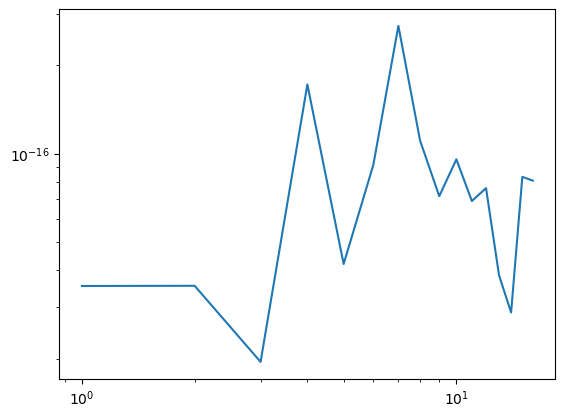

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sym

ks = np.arange(1, 17)
y1_err = []

for k in ks :
    xk = 10.0**(-k)
    y1_ref = sym.N(1 - sym.cos(10**sym.Integer(-k)), 50) #per maggior precisione

    y1_std = 1 - np.cos(xk)

    err = np.abs(y1_std - y1_ref) / np.abs(y1_ref)

    y1_err.append(err)
    
xk = 10.0**(-ks)
plt.loglog(ks, y1_err)

plt.show()

y1_err = []
for k in ks :
    xk = 10.0**(-k)
    y1_ref = sym.N(1 - sym.cos(10**sym.Integer(-k)), 50)

    yk_std = (np.sin(xk)**2) / (1 + np.cos(xk))  # 1-cos(x) * 1 + cos(x) / 1 + cos(x) = 1-cos^2(x) / 1 + cos(x) = sen^2(x) / 1 + cos(x)

    err = np.abs(yk_std - y1_ref) / np.abs(y1_ref)

    y1_err.append(err)
xk = 10.0**(-ks)
plt.loglog(ks, y1_err)

La cancellazione catastrofica si verifica nella sottrazione $1 - \cos(x_k)$ poiché, per $x_k$ molto piccoli, il coseno tende a $1$, costringendo il computer a sottrarre due numeri quasi identici. Approssimando con Taylor ($\cos(x_k) \approx 1 - \frac{x_k^2}{2}$), deduciamo che la quantità effettivamente sottratta a $1$ è $\frac{x_k^2}{2}$. Il limite si raggiunge quando questo termine diventa inferiore allo spacing di macchina (circa $10^{-16}$). Imponendo $\frac{x_k^2}{2} < 10^{-16}$, troviamo che per $x_k \le 10^{-8}$ (ovvero per $k \ge 8$) la differenza non viene più rilevata: il calcolatore arrotonda il coseno a $1$ e il risultato collassa a zero.




L'implementazione mostra chiaramente la netta differenza di stabilità tra le due formule. Come si evince dal grafico, l'errore relativo della formula diretta esplode per valori di $x_k$ tendenti a zero a causa della cancellazione catastrofica. Al contrario, la formula stabile mantiene un errore relativo minimo e costante, limitato al solo rumore di arrotondamento nell'ordine della precisione di macchina (circa $10^{-16}$). Questo risultato è giustificato dal fatto che la nuova formula sostituisce la sottrazione critica con una divisione che presenta al denominatore una somma di termini concettualmente positivi e vicini a uno ($1 + \cos(x_k)$), eliminando del tutto la perdita di cifre significative e rendendo il calcolo numericamente sicuro.